In [ ]:
import h5ify
import matplotlib.pyplot as plt

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

In [ ]:
def log_model():
    tau = log_iid_spin_tilt_truncnorm(dataset, parameters)
    tau_iso = jnp.log(1 / 4) # Unif in cos tilt 1 and 2, each on [-1, 1]

    chi = log_iid_spin_mag_truncnorm(dataset, parameters)
    chi_iso = log_iid_spin_mag_truncnorm(dataset, parameters, key='iso')
    chi_high_iso = log_iid_spin_mag_truncnorm(
        dataset, parameters, key='high_iso'
    )

    xi = parameters.get('xi_spin', 1)
    zeta = parameters.get('zeta', 0)

    if 'transition_mass' in parameters:
        m1 = dataset.get('mass_1_source', dataset.get('mass_1'))
        mtilde = parameters['transition_mass']
        zeta = jax.scipy.special.expit(m1 - mtilde)

    log_mass = log_bpl2p_m1q(dataset, parameters)
    log_mass_iso = log_bpl2p_m1q(dataset, parameters, key='iso')

    log_branch_0 = jnp.log(1 - zeta) + jnp.log(xi)
    log_branch_1 = jnp.log(1 - zeta) + jnp.log(1 - xi)
    log_branch_2 = jnp.log(zeta)

    return (
        log_branch_0,
        log_branch_1,
        log_branch_2,
        
    )

    gauss = jnp.log(1 - zeta) + jnp.log(xi) + tau + chi + log_mass
    iso_low_mass = jnp.log(1 - zeta) + jnp.log(1 - xi) + tau_iso + chi_iso + log_mass_iso
    iso_high_mass = jnp.log(zeta) + tau_iso + chi_high_iso + log_mass_iso



In [2]:
prior = h5ify.load('./test/prior.h5')

In [7]:
prior.keys()

dict_keys(['ln_lkl', 'ln_pdet', 'ln_pdet_variance', 'pe_variance', 'samples', 'variance'])

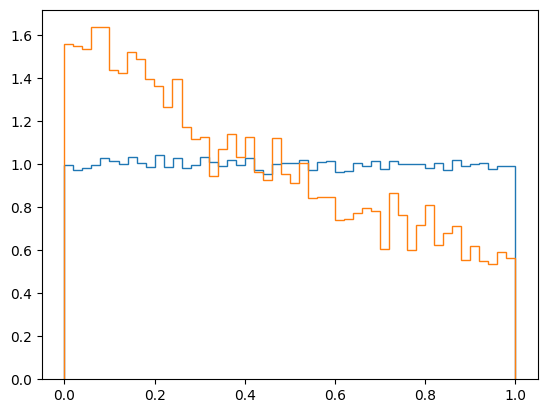

In [3]:
mask = prior['variance'] < 1
xs = prior['samples']['xi_spin']

fig, ax = plt.subplots()
ax.hist(xs, histtype='step', bins=50, density=True)
ax.hist(
    xs[mask],
    histtype='step',
    bins=50,
    density=True
);